# Bayesian uncertainty quantification Jupyter notebook

In [1]:
import numpy as np
import corner
import matplotlib.pyplot as plt
import scipy
import pandas as pd

plt.rcParams['figure.figsize']=(14.4,7.4)

#Some pretty colors I like
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [2]:
# reading the oslo data for 300 bin (6,9)

df=pd.read_csv("gsf_300(6,9).csv")

# convert to python arrays
energy1=df["energy"].values # as numpy array
gsf1=df["gsf"].values 
error1=df["errors"].values




In [3]:
# add 96Zr data points as well

df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\96Zr_photonuclear.txt",delimiter="\s+")
df_96.columns=['energy','dE','gsf','error']

#plt.errorbar(df_96['energy'], df_96['gsf'],yerr=df_96['errors'],fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')

# convert to python arrays
energy2=df_96["energy"].values # as numpy array
gsf2=df_96["gsf"].values 
error2=df_96["error"].values


energy = np.concatenate((energy1,energy2), axis=0)
gsf = np.concatenate((gsf1,gsf2), axis=0)
error = np.concatenate((error1,error2), axis=0)


print(energy)

[ 1.341  1.641  1.941  2.241  2.541  2.841  3.141  3.441  3.741  4.041
  4.341  4.641  4.941  5.241  5.541  5.841  6.141  6.441  7.97   8.15
  8.5    8.66   8.88   9.06   9.29   9.67  10.05  10.98  11.86  12.67 ]


<>:3: SyntaxWarning: invalid escape sequence '\9'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\9'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\amals\AppData\Local\Temp\ipykernel_34596\190093728.py:3: SyntaxWarning: invalid escape sequence '\9'
  df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\96Zr_photonuclear.txt",delimiter="\s+")
C:\Users\amals\AppData\Local\Temp\ipykernel_34596\190093728.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\96Zr_photonuclear.txt",delimiter="\s+")


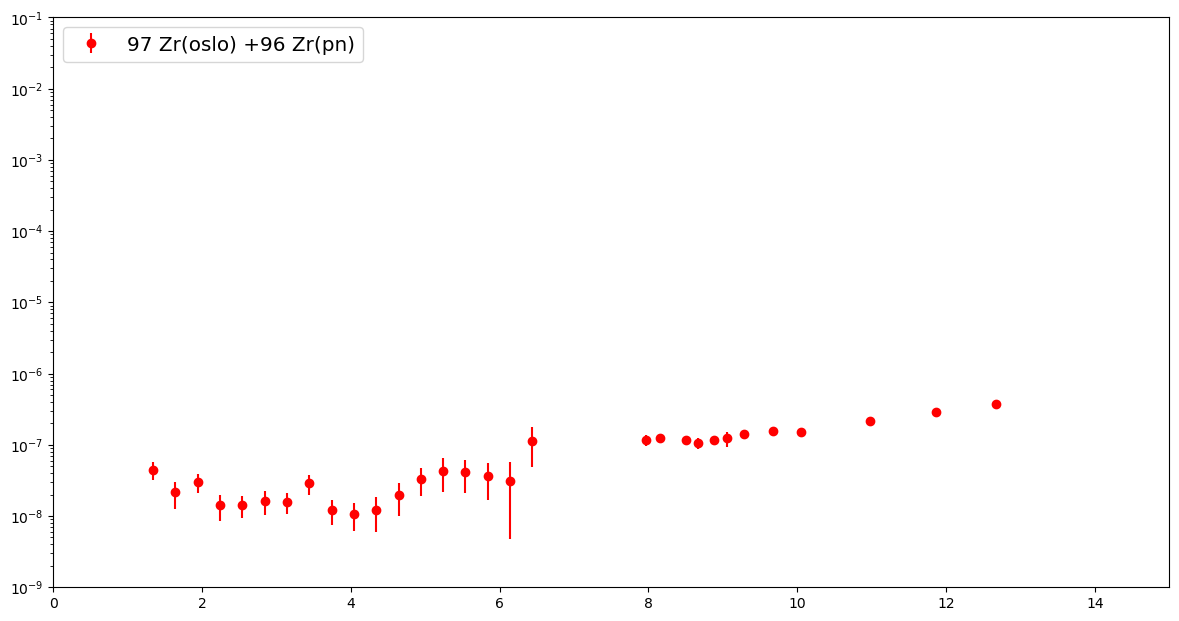

In [4]:
# Plot the oslo data with error bars

fig = plt.figure()


plt.errorbar(energy, gsf,yerr=error,fmt="o", color="r",ecolor='r',label='97 Zr(oslo) +96 Zr(pn)')

#plt.errorbar(df_96['energy'], df_96['gsf'],yerr=df_96['error'],fmt="o", color="b",ecolor='b',label='96 Zr photo nuclear')

plt.yscale("log")

plt.xlim(0, 15)
plt.ylim(10**(-9),10**(-1))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

<font size="5">
The model we will use to fit to this data set is:
    
    

strength 8 , strength M1 2

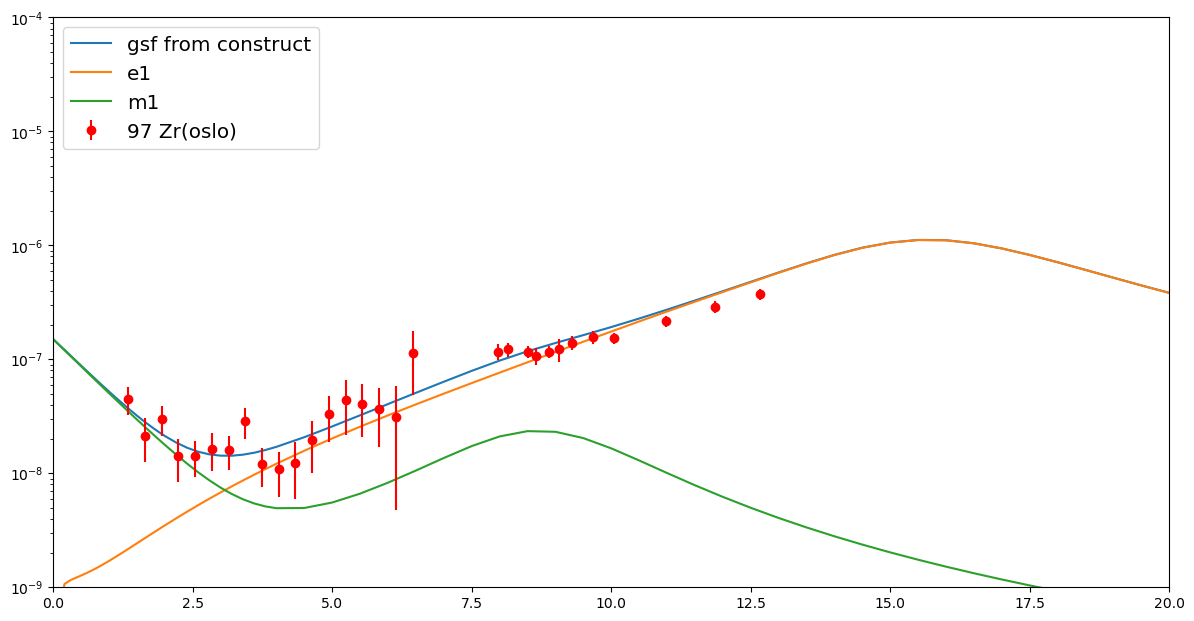

In [6]:
df_construct = pd.read_pickle("master_base_gsf.pkl")

df_base = df_construct.copy()

# base values
# f(E1)
ftable=1
C= 10**(-10)
U =  5.569156
eta =3

#f(M1)
upbende =1.1
upbendc = 1.5*10**(-7)

# f(e1) construction
df_construct['f(E1)']= ftable * df_construct['f(E1)']+  (C* (U-df_construct['energy']))/(1+np.exp(df_construct['energy']-eta))

#f(m1) construction
df_construct['f(M1)']=  df_construct['f(M1)']+  upbendc * np.exp(-1*upbende*df_construct['energy'])

df_construct['gsf'] = df_construct['f(E1)']+ df_construct['f(M1)']


plt.plot(df_construct['energy'], df_construct['gsf'], label ='gsf from construct')
plt.plot(df_construct['energy'], df_construct['f(E1)'], label ='e1')
plt.plot(df_construct['energy'], df_construct['f(M1)'], label ='m1')


plt.errorbar(energy, gsf,yerr=error,fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')



plt.yscale("log")

plt.xlim(0, 20)
plt.ylim(10**(-9),10**(-4))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()



<font size="5">
Linear interpolation

In [8]:
#linear interpolation for the talys values on energy/x in the oslo data
# needed for the likelihood function


intp_gsf = np.interp(energy, df_construct['energy'].values, df_construct['gsf'].values)
intp_e1 = np.interp(energy,  df_construct['energy'].values, df_construct['f(E1)'].values)
intp_m1 = np.interp(energy, df_construct['energy'].values, df_construct['f(M1)'].values)



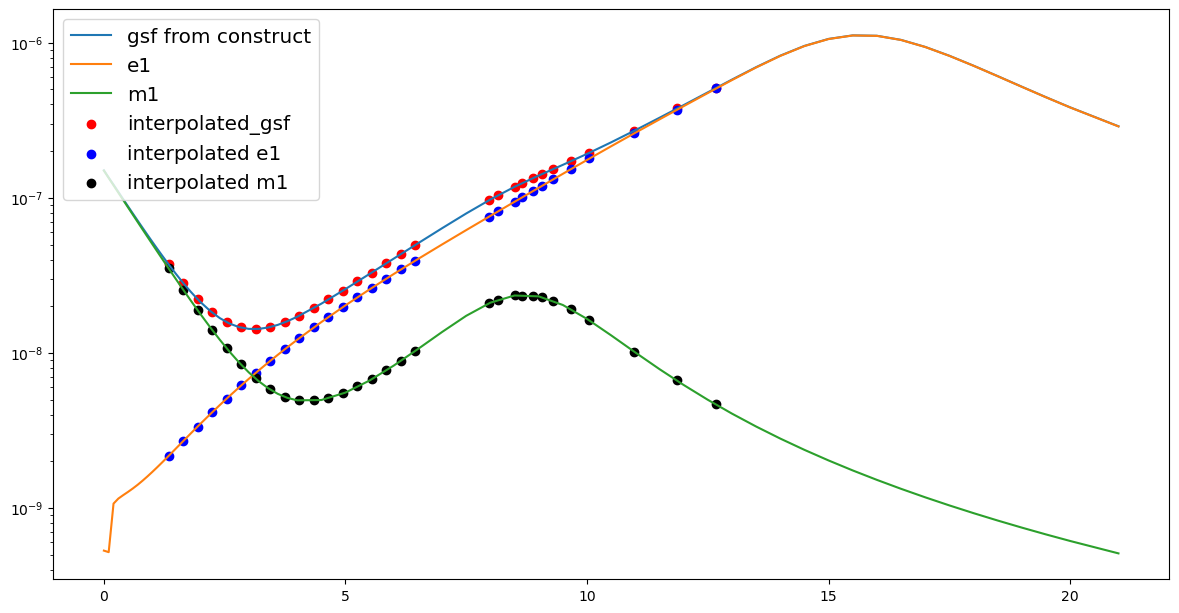

30


In [9]:
#verification whether the interpolation did its job!!! interpolated data vs model

fig = plt.figure()

plt.plot(df_construct['energy'], df_construct['gsf'], label ='gsf from construct')
plt.plot(df_construct['energy'], df_construct['f(E1)'], label ='e1')
plt.plot(df_construct['energy'], df_construct['f(M1)'], label ='m1')



plt.scatter(energy,intp_gsf,label='interpolated_gsf', color='r')
plt.scatter(energy, intp_e1, label ='interpolated e1' ,color ='blue')
plt.scatter(energy, intp_m1, label ='interpolated m1', color = 'black')




plt.yscale("log")

#plt.xlim(0, 10)
#plt.ylim(10**(-9),10**(-4))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()


print(intp_gsf.size)

Bayesian starts here

In [11]:
#intrapoltaion of base

int_gsf = np.interp(energy, df_base['energy'].values, df_base['gsf'].values)
int_e1 = np.interp(energy,  df_base['energy'].values, df_base['f(E1)'].values)
int_m1 = np.interp(energy, df_base['energy'].values, df_base['f(M1)'].values)




In [13]:
'''
# f(e1)  --- constants
ftable=1
C= 10**(-10)
U =  5.569156
eta =3
    
#f(M1)-- constants
upbende =1.1
upbendc = 1.5*10**(-7)
    

# f(e1) values    
e1= ftable *  int_e1 +  (C* (U-energy))/(1+np.exp( energy-eta))
    
#f(m1) construction
m1 =  int_m1 +  upbendc * np.exp(-1*upbende*energy)

gsf_t = m1+e1

plt.plot(energy,e1, color ='r' )
plt.plot(energy,m1, color ='b' )
plt.plot(energy,gsf_t, color ='green' )

plt.errorbar(energy, gsf,yerr=error,fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')


plt.yscale("log")

plt.xlim(0, 20)
plt.ylim(10**(-9),10**(-4))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()'''

'\n# f(e1)  --- constants\nftable=1\nC= 10**(-10)\nU =  5.569156\neta =3\n    \n#f(M1)-- constants\nupbende =1.1\nupbendc = 1.5*10**(-7)\n    \n\n# f(e1) values    \ne1= ftable *  int_e1 +  (C* (U-energy))/(1+np.exp( energy-eta))\n    \n#f(m1) construction\nm1 =  int_m1 +  upbendc * np.exp(-1*upbende*energy)\n\ngsf_t = m1+e1\n\nplt.plot(energy,e1, color =\'r\' )\nplt.plot(energy,m1, color =\'b\' )\nplt.plot(energy,gsf_t, color =\'green\' )\n\nplt.errorbar(energy, gsf,yerr=error,fmt="o", color="r",ecolor=\'r\',label=\'97 Zr(oslo)\')\n\n\nplt.yscale("log")\n\nplt.xlim(0, 20)\nplt.ylim(10**(-9),10**(-4))\n\nplt.legend(loc =\'upper left\',fontsize="x-large")\nplt.show()'

In [14]:
# this goes into metropolis algorithm
def model_8(j,params):

    # f(e1)  --- constants
    ftable=1
    C= 10**(-10)
    U =  5.569156
    eta =3
    
    #f(M1)-- constants
    upbende =1.1
    upbendc = 10**(-6)
    
    # f(e1) construction
    e1= params[0]*ftable * int_e1[j] +  (C* (U-energy[j]))/(1+np.exp(energy[j]-eta))
    
    #f(m1) construction
    m1 = int_m1[j] +  params[1]*upbendc * np.exp(-1*(upbende*params[2])*energy[j])
    
    gsf_t = m1+e1
    
    return gsf_t


In [15]:
# this is drawing at final stage

def model_all(params):

     # f(e1)  --- constants
    ftable=1
    C= 10**(-10)
    U =  5.569156
    eta =3
    
    #f(M1)-- constants
    upbende =1.1
    upbendc = 10**(-6)
    
    # f(e1) construction
    e1= params[0]*ftable *  df_base['f(E1)'].values +  (C* (U-df_base['energy'].values))/(1+np.exp( df_base['energy'].values-eta))
    
    #f(m1) construction
    m1 =  df_base['f(M1)'].values +  params[1]*upbendc * np.exp(-1*(upbende*params[2])*df_base['energy'].values)

    gsf_t2 = m1+e1
    
    return gsf_t2

In [313]:

# Define the likelihood function for given errors sigma
def likelihood(params,arguments):
#Assumed format for data=[xvals,yvals]
    data, model, sigmas = arguments
    likelihood_log_val=0

    for i in range(len(data[0])):
        likelihood_log_val=likelihood_log_val-1/2*((data[1][i] - model(i,params)) / sigmas[i])**2\
        -np.log(2*np.pi*sigmas[i]**2)/2
      
        
    return np.exp(likelihood_log_val)

def prior_model_8(params_vals,arguments):
    params0,params0_Cov_Inv_matrix=arguments

   
    mu=np.array(params_vals)-np.array(params0)
    params_size=len(params_vals)
    return (2*np.pi)**(-params_size/2)*np.sqrt(np.linalg.det(params0_Cov_Inv_matrix))*np.exp(-np.dot(mu,np.dot(params0_Cov_Inv_matrix,mu))/2)




In [491]:
# Define the Metropolis algorithm
def metropolis(data,sigma, prior,prior_arguments, likelihood,model,\
               num_iterations, step_size):
#     step_size should be a list the size of the parameters of the model
    likelihood_arguments=[data, model, sigma]
    initial_parameters=prior_arguments[0]
    #thermalizing
    burn_samples=10000
    # Set the initial state of the chain
    params_current=initial_parameters
    params_list=[]
    posterior_list=[]
    
    acceptance_times=0
    
    cov_step_size=np.diag(step_size)**2
    
    posterior_current=(likelihood(params_current,likelihood_arguments))*(prior(params_current,\
                                                                               prior_arguments))
    
    # Run the Metropolis-Hastings algorithm for burning
    for i in range(burn_samples):
        # Propose a new state for the chain
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*(prior(params_proposed,\
                                                                               prior_arguments))
        
        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed


    for i in range(num_iterations):
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*\
        (prior(params_proposed,prior_arguments))
        
        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed
            acceptance_times=acceptance_times+1

        # Store the current state
        params_list.append(params_current)
        posterior_list.append(posterior_current)
        
    
    #Rule of thumb acceptance is around 50%. 
    #You could plot the accuracy of the estimations as a function of this rate, that would be interesting to see. 
    print(acceptance_times/num_iterations*100,"%")
    
    return(np.array(params_list),np.array(posterior_list),\
           acceptance_times/num_iterations*100)




In [493]:

#Setting up the prior


#prior_arguments_A=[[0.1,0.2,0.1],np.linalg.inv(np.diag([5**2,5**2,5**2]))]


prior_arguments_A=[[0.0,0.0,0.0],np.linalg.inv(np.diag([5**2,5**2,5**2]))]

#prior_arguments_A=[[1.43,2.43,1.45],np.linalg.inv(np.diag([10**2,2**2,10**2]))]

#Doing the Metropolis sampling for 100000 values
results_A=metropolis([energy,gsf],error, prior_model_8,\
                         prior_arguments_A, likelihood,model_8,100000, [0.08,0.06,0.02])
all_chains =results_A[0]

print(all_chains)

#0.008,0.2,0.2
#0.008,0.3,0.09

# [0.008,0.03,0.09] best with 5**2 and constraint on upbend

# [0.08,0.04,0.02]  but now constraint is reduced

# [0.08,0.09,0.09] best works well

# [0.04,0.07,0.02] more best
# [0.04,0.09,0.02] even better

# [0.04,0.10,0.02]
#[0.04,0.20,0.02]

# with 10^(-6) constraint
#[0.08,0.06,0.02] the best

34.192 %
[[0.92530888 0.22774987 1.27212492]
 [0.85314684 0.33700943 1.22867125]
 [0.85314684 0.33700943 1.22867125]
 ...
 [0.84575934 0.15482862 1.0244224 ]
 [0.84575934 0.15482862 1.0244224 ]
 [0.84575934 0.15482862 1.0244224 ]]


In [495]:
print(all_chains.shape)

(100000, 3)


(100000,)


(0.0, 100000.0)

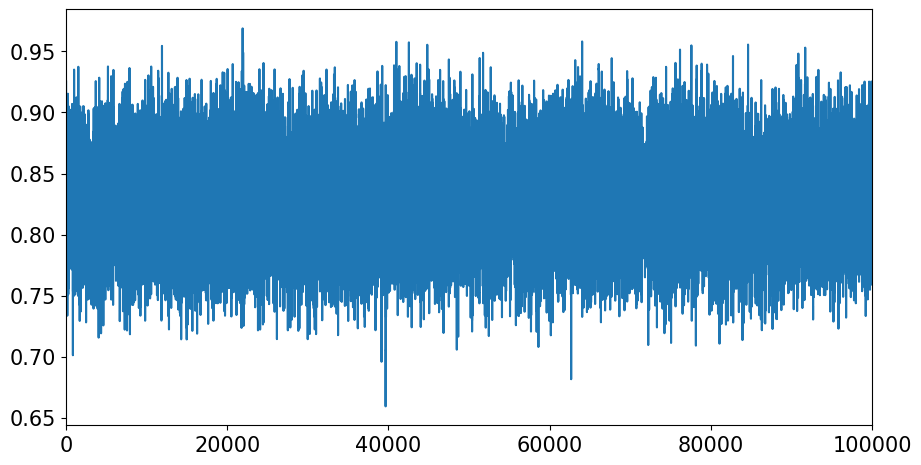

In [497]:
b =np.arange((100000))
b=b+1
print(b.shape)

plt.plot(b,all_chains[:,0])

plt.xlim(0,100000)

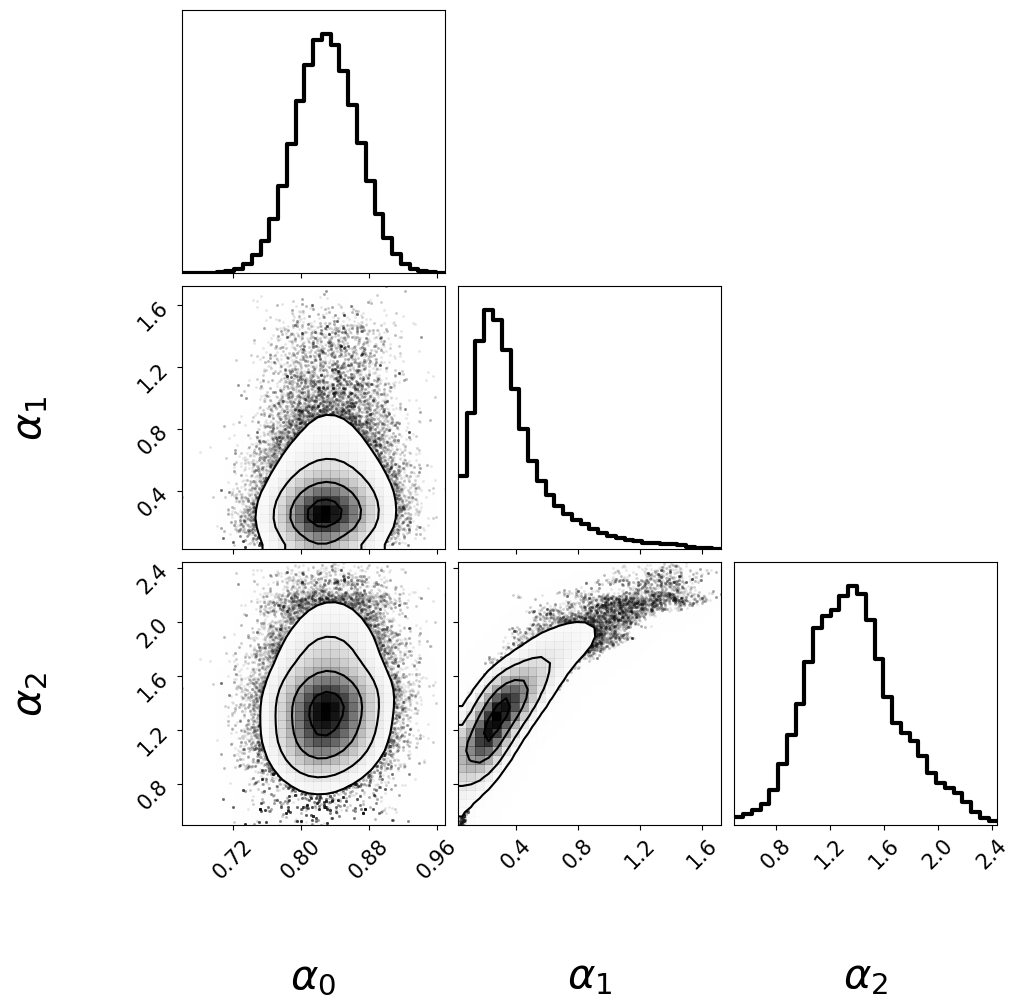

In [500]:
figure = corner.corner(
    all_chains,
    labels=[r'$\alpha_0$', r'$\alpha_1$', r'$\alpha_2$'],
    labelpad=0.2,
    bins=30,
    label_kwargs={"fontsize":30},
    hist_kwargs={"linewidth":3},
    smooth=1.7,
    smooth1d=1.0
)

width, height = 10, 10  # bigger for 3 params
figure.set_size_inches(width, height)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

#plt.savefig(r"contour plots_gsf.jpg", format='jpg', dpi=300, bbox_inches='tight')


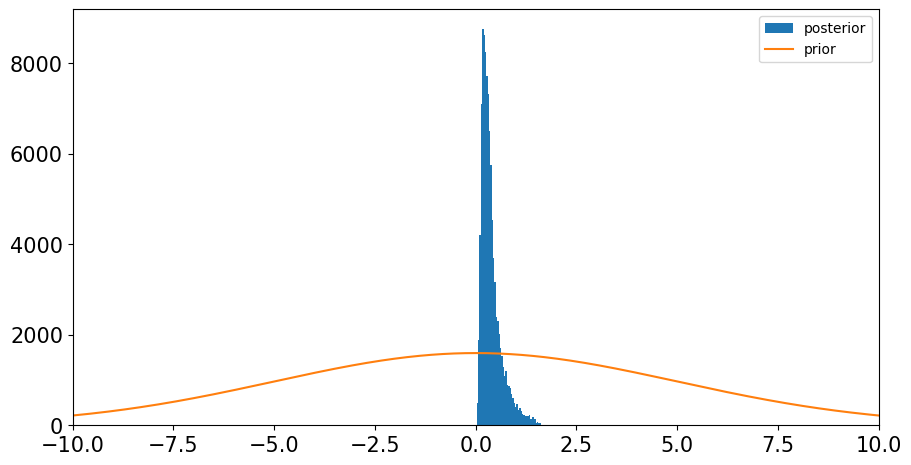

In [533]:
plt.hist(all_chains[:,1], bins=50,label='posterior')

mu = 0    # center
sigma = 5   # standard deviation

x = np.linspace(mu - 2*sigma, mu + 2*sigma, 500)

y = 20000*(1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))

plt.plot(x, y,label='prior')

plt.xlim(-10,10)
#plt.plot(x, norm.pdf(x, mu, sigma))
plt.legend()
plt.show()


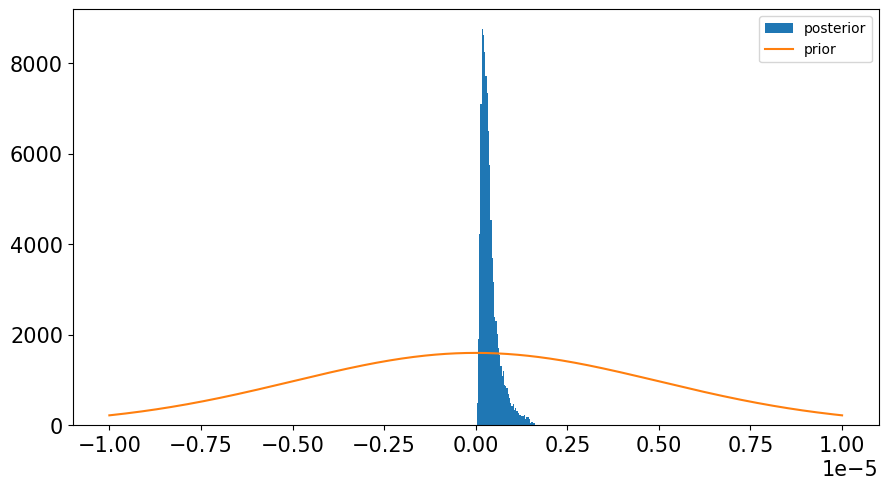

In [563]:
ex = all_chains[:,1]*10**(-6)

plt.hist(ex, bins=50,label='posterior')



mu = 0    # center
sigma = 5*10**(-6)   # standard deviation

x = np.linspace(mu - 2*sigma, mu + 2*sigma, 500) 

y = 0.02*(1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))

plt.plot(x, y,label='prior')

#plt.xlim(-10**(-6),10**(-6))

plt.legend()
plt.show()

In [503]:
#Taking 10000 samples from the visited posterior to estimate the percentiles in the model predictions

rng = np.random.default_rng()
alpha_rand = rng.choice(all_chains,(10000),replace=False)


print(alpha_rand)

min_idx = np.argmin(alpha_rand[:, 1])

print(min_idx)
print(alpha_rand[101])

[[0.83892339 0.57334238 1.74050055]
 [0.79477697 0.4303941  1.49601549]
 [0.86841337 0.2378423  1.2012038 ]
 ...
 [0.83660182 0.3659128  1.41373767]
 [0.84112355 0.29564606 1.35879977]
 [0.86620115 0.3432781  1.20773771]]
5036
[0.80204551 0.38208868 1.40810171]


In [506]:

rng2 = np.random.default_rng()
alpha_rand2 = rng2.choice(all_chains,(150),replace=False)

#np.savetxt('file2.txt', alpha_rand2, fmt='%.6f')


print(alpha_rand2)
# initial 

[[0.80140535 0.09959303 0.87031991]
 [0.81510285 0.24747356 1.05576412]
 [0.84284233 0.24245645 1.16505623]
 [0.8705917  1.08505644 2.17704916]
 [0.80851638 0.27799229 1.26086818]
 [0.85008483 0.26442381 1.19237747]
 [0.81214825 1.10104943 2.15790188]
 [0.87666109 0.36750463 1.54718866]
 [0.8320893  0.28331052 1.25487688]
 [0.83246233 0.21227426 1.15083473]
 [0.79310827 0.48602501 1.47304513]
 [0.91010878 1.14995965 2.1370633 ]
 [0.87475795 0.22949651 1.09635304]
 [0.85730436 0.09386551 0.79201778]
 [0.81603901 0.31771692 1.36011698]
 [0.81715343 0.41204583 1.71322971]
 [0.82076399 0.60470583 1.7367277 ]
 [0.87162542 0.69892705 1.85646481]
 [0.8767508  0.39141392 1.46155868]
 [0.80258049 0.51280245 1.58711013]
 [0.84511074 0.31849331 1.31990989]
 [0.83312446 0.38084621 1.66170028]
 [0.81452161 0.51630446 1.54379651]
 [0.87308202 1.12376679 1.96329188]
 [0.848649   1.46355304 2.12223978]
 [0.83473422 0.42465615 1.48989079]
 [0.83805592 0.42604479 1.57542979]
 [0.87384912 0.74027962 2.22

In [508]:
# initial guess

df8=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\talys\\what is talys actually doing to gsf\\new_best_talys for 97Zr\\gsf.txt",delimiter="\s+",skiprows=2,header=None)
# some shit i tried, i am tired
#df8=pd.read_table("C:\\Users\\amals\\Downloads\\randomgsf.txt",delimiter="\s+",skiprows=2,header=None)
df8.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']
df8['gsf'] = df8['f(M1)'] + df8['f(E1)']


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\amals\AppData\Local\Temp\ipykernel_45828\2632466693.py:3: SyntaxWarning: invalid escape sequence '\s'
  df8=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\talys\\what is talys actually doing to gsf\\new_best_talys for 97Zr\\gsf.txt",delimiter="\s+",skiprows=2,header=None)


Lets make a plot of the predictions of our calibrated model

(69,)
(69,)


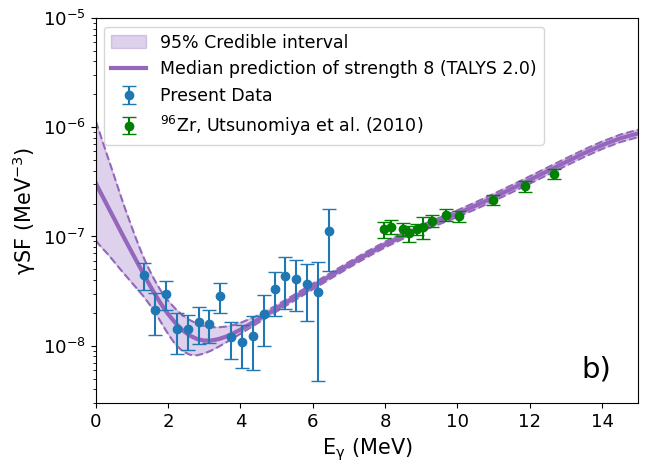

In [511]:
plt.rcParams['figure.figsize']=(10.4,5.4)



np.random.seed(142857)




func_rand=[model_all(alpha) for alpha in alpha_rand]

fig, ax = plt.subplots(figsize=(7,5),dpi=100)
median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))

prediction_color_number=4

lower = (np.percentile(func_rand, 2.5, axis = 0))


print(upper.shape)
print(lower.shape)

ax.fill_between(df_base['energy'].values, lower, upper, color=colors[prediction_color_number], alpha=0.3,label='95% Credible interval')

ax.plot(df_base['energy'].values, median, color=colors[prediction_color_number],linewidth=3,label='Median prediction of strength 8 (TALYS 2.0)')
ax.plot(df_base['energy'].values, lower, color=colors[prediction_color_number],linestyle='dashed')
ax.plot(df_base['energy'].values, upper, color=colors[prediction_color_number],linestyle='dashed')


#ax.plot(df8['energy'],df8['gsf'], color='black', label ='Initial fit of strength 8')
#ax.plot(df_base['energy'].values, func_rand[3072], color='green',linestyle='dashed')
#plt.plot(energy_t,gsf_t,color='r',label='strength 9 model')
#If you want to see the true function that generated these, uncomment the following line
# ax.plot(x_func, true_function_A(x_func), label='True Function',color='r', alpha=0.6)

ax.errorbar(energy1, gsf1, yerr=error1, fmt='o', capsize=5,label='Present Data')


ax.errorbar(energy2, gsf2, yerr=error2, fmt='o',color='green', capsize=5,label=r'$^{96}\mathrm{Zr}$, Utsunomiya et al. (2010)')



#plt.plot(energy_t,gsf_t,color='orange',label='gsf from talys ')


# other nearby isotope data points
df_92=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\\92Zr_photonuclear.txt",delimiter=r"\s+")
df_92.columns=['energy','dE','gsf','errors']

df_94=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\\94Zr_photonuclear.txt",delimiter=r"\s+")
df_94.columns=['energy','dE','gsf','errors']

df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\\96Zr_photonuclear.txt",delimiter=r"\s+")
df_96.columns=['energy','dE','gsf','errors']

#plt.plot(df1['energy'], df1['gsf'],color='b')
#plt.errorbar(df_92['energy'], df_92['gsf'],yerr= df_92['errors'],fmt="o", color="green",ecolor='green',label='$^{92}$Zr(photo-neutron)')

#plt.plot(df2['energy'], df2['gsf'],color='r')
#plt.errorbar(df_94['energy'], df_94['gsf'],yerr= df_94['errors'],fmt="o", color="r",ecolor='r',label='$^{94}$Zr(photo-neutron)')

#plt.plot(df3['energy'], df3['gsf'],color='black')
#plt.errorbar(df_96['energy'], df_96['gsf'],yerr= df_96['errors'],fmt="o", color="black",ecolor='black',label='$^{96}$Zr(photo-neutron)')



plt.legend(fontsize=15,frameon=True, edgecolor='black')



plt.yscale("log")



plt.xlim(0, 15)
plt.ylim(3*10**(-9),10**(-5))


ax.set_xlabel(r'E$_{\mathrm{\gamma}}$ ($\mathrm{MeV}$)', fontsize=15)
ax.set_ylabel(r'$\mathrm{\gamma}$SF (MeV$^{-3}$)',fontsize=15)

#plt.rc('xtick', labelsize=13)   
#plt.rc('ytick', labelsize=13)


plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)


plt.legend(loc ='upper left', fontsize=12.5)

ax.text(0.95, 0.05, 'b)', transform=ax.transAxes,
        fontsize=21, va='bottom', ha='right')

plt.savefig(r"bayesian_gsf.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()



What if we want to predict the value of f at a specific location? For example x=3

In [664]:
df_low=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\bayesian\\300(6,9)_test\\gsf_low.txt",delimiter=r"\s+",skiprows=2,header=None)
df_low.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']
df_low['gsf'] = df_low['f(M1)'] + df_low['f(E1)']

df_low

,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,9.989010e-08,9.633270e-10,6.276280e-16,1.503010e-17,1.008534e-07
1,0.002,9.978110e-08,9.638750e-10,5.015550e-15,1.202650e-16,1.007450e-07
2,0.005,9.945360e-08,9.655260e-10,7.811070e-14,1.880280e-15,1.004191e-07
3,0.010,9.891020e-08,9.682980e-10,6.214710e-13,1.505750e-14,9.987850e-08
4,0.020,9.783240e-08,9.739190e-10,4.917590e-12,1.207080e-13,9.880632e-08
...,...,...,...,...,...,...
64,18.500,6.558520e-10,4.324180e-07,2.609160e-05,1.720280e-02,4.330739e-07
65,19.000,5.903200e-10,3.703780e-07,2.544060e-05,1.596190e-02,3.709683e-07
66,19.500,5.335510e-10,3.177090e-07,2.485760e-05,1.480170e-02,3.182426e-07
67,20.000,4.840940e-10,2.736600e-07,2.433320e-05,1.375560e-02,2.741441e-07


In [665]:
df_high=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\bayesian\\300(6,9)_test\\gsf_high.txt",delimiter=r"\s+",skiprows=2,header=None)
df_high.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']
df_high['gsf'] = df_high['f(M1)'] + df_high['f(E1)']

df_high

,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,1.698130e-07,1.179800e-09,1.066970e-15,1.639030e-17,1.709928e-07
1,0.002,1.696280e-07,1.180680e-09,8.526420e-15,1.311630e-16,1.708087e-07
2,0.005,1.690710e-07,1.183340e-09,1.327880e-13,2.051350e-15,1.702543e-07
3,0.010,1.681460e-07,1.187800e-09,1.056500e-12,1.643670e-14,1.693338e-07
4,0.020,1.663130e-07,1.196830e-09,8.359820e-12,1.319130e-13,1.675098e-07
...,...,...,...,...,...,...
64,18.500,9.837780e-10,6.486260e-07,3.913740e-05,2.580420e-02,6.496098e-07
65,19.000,8.854800e-10,5.555670e-07,3.816100e-05,2.394290e-02,5.564525e-07
66,19.500,8.003270e-10,4.765630e-07,3.728650e-05,2.220260e-02,4.773633e-07
67,20.000,7.261410e-10,4.104890e-07,3.649980e-05,2.063340e-02,4.112151e-07


NameError: name 'energy_t' is not defined

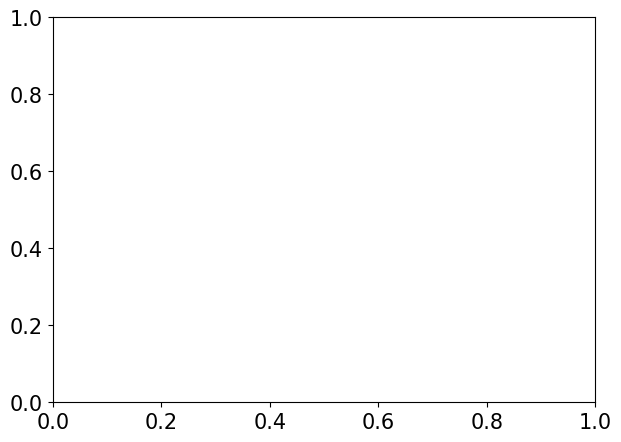

In [669]:
fig, ax = plt.subplots(figsize=(7,5),dpi=100)


ax.fill_between(energy_t, lower, upper, color=colors[prediction_color_number], alpha=0.3,label='95% Credible BAND')

ax.plot(energy_t, median, color=colors[prediction_color_number],linewidth=3,label='Median prediction')
ax.plot(energy_t, lower, color=colors[prediction_color_number],linestyle='dashed')
ax.plot(energy_t, upper, color=colors[prediction_color_number],linestyle='dashed')



#talys upper and lower tests

plt.plot(df_low['energy'], df_low['gsf'],color='red',label='strength-model8-talys-low')

plt.plot(df_high['energy'], df_high['gsf'],color='red',label='strength-model8-talys-high')

plt.legend(fontsize=15,frameon=True, edgecolor='black')
plt.yscale("log")
plt.xlim(0, 8)
#plt.ylim(10**(-9),10**(-5))


ax.set_xlabel('energy(MeV)',fontsize=20)
ax.set_ylabel('gsf',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)


plt.legend(loc ='upper left')
plt.show()